이미지 데이터 세트

In [1]:
# 터미널에서 실행
# wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DL0110EN-SkillsNetwork/labs/Week1/data/img.tar.gz -OutFile ./Practices/AIE/C4/resources/data/img.tar.gz
# tar -xf ./Practices/AIE/C4/resources/data/img.tar.gz -C ./Practices/AIE/C4/resources/data
# wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DL0110EN-SkillsNetwork/labs/Week1/data/index.csv -OutFile ./Practices/AIE/C4/resources/data/index.csv

In [15]:
import torch 
import matplotlib.pylab as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
torch.manual_seed(0)

In [16]:
from matplotlib.pyplot import imshow
import matplotlib.pylab as plt
from PIL import Image
import pandas as pd
import os

In [19]:
def show_data(data_sample, shape = (28, 28)):
    plt.imshow(data_sample[0].numpy().reshape(shape), cmap='gray')
    plt.title('y = ' + data_sample[1])

In [34]:
current_path = os.getcwd()
data_path = os.path.join(current_path, "resources/data")
csv_path = os.path.join(data_path, "index.csv")

print(current_path)
print(data_path)
print(csv_path)

d:\Project\Python\PyLab\Practices\AIE\C4
d:\Project\Python\PyLab\Practices\AIE\C4\resources/data
d:\Project\Python\PyLab\Practices\AIE\C4\resources/data\index.csv


In [35]:
data_name = pd.read_csv(csv_path)
data_name.head()

,category,image
0,Ankle boot,img/fashion0.png
1,T-shirt,img/fashion1.png
2,T-shirt,img/fashion2.png
3,Dress,img/fashion3.png
4,T-shirt,img/fashion4.png


In [36]:
print('File name:', data_name.iloc[0, 1])

File name: img/fashion0.png


In [37]:
print('y:', data_name.iloc[0, 0])

y: Ankle boot


In [38]:
print('File name:', data_name.iloc[1, 1])
print('class or y:', data_name.iloc[1, 0])

File name: img/fashion1.png
class or y: T-shirt


In [39]:
print('The number of rows: ', data_name.shape[0])

The number of rows:  60000


In [40]:
image_name = data_name.iloc[1, 1]
image_name

'img/fashion1.png'

In [41]:
image_path=os.path.join(data_path, image_name)
image_path

'd:\\Project\\Python\\PyLab\\Practices\\AIE\\C4\\resources/data\\img/fashion1.png'

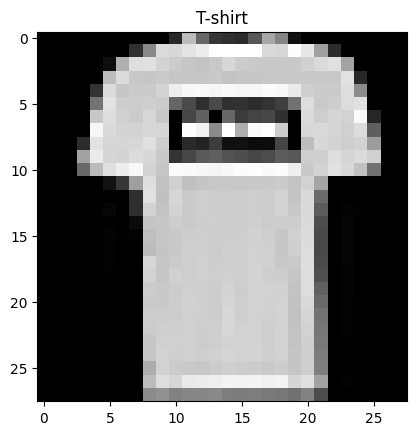

In [42]:
image = Image.open(image_path)
plt.imshow(image,cmap='gray', vmin=0, vmax=255)
plt.title(data_name.iloc[1, 0])
plt.show()

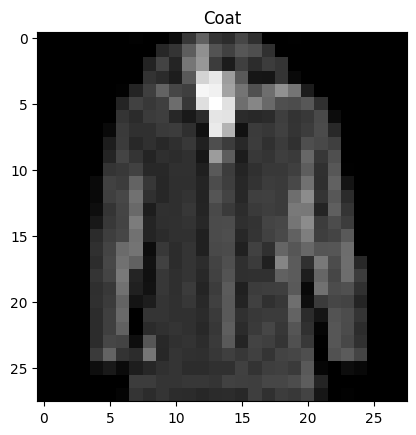

In [43]:
image_name = data_name.iloc[19, 1]
image_path=os.path.join(data_path,image_name)
image = Image.open(image_path)
plt.imshow(image,cmap='gray', vmin=0, vmax=255)
plt.title(data_name.iloc[19, 0])
plt.show()

In [44]:
# Create your own dataset object
class Dataset(Dataset):

    # Constructor
    def __init__(self, csv_file, data_dir, transform=None):
        
        # Image directory
        self.data_dir=data_dir
        
        # The transform is goint to be used on image
        self.transform = transform
        data_dircsv_file=os.path.join(self.data_dir,csv_file)
        # Load the CSV file contians image info
        self.data_name= pd.read_csv(data_dircsv_file)
        
        # Number of images in dataset
        self.len=self.data_name.shape[0] 
    
    # Get the length
    def __len__(self):
        return self.len
    
    # Getter
    def __getitem__(self, idx):
        
        # Image file path
        img_name=os.path.join(self.data_dir,self.data_name.iloc[idx, 1])
        # Open image file
        image = Image.open(img_name)
        
        # The class label for the image
        y = self.data_name.iloc[idx, 0]
        
        # If there is any transform method, apply it onto the image
        if self.transform:
            image = self.transform(image)

        return image, y

In [45]:
dataset = Dataset(csv_file=csv_path, data_dir=data_path)

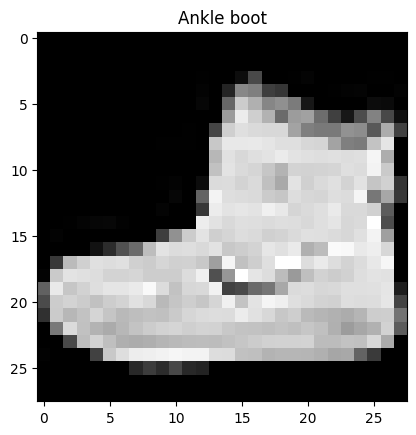

In [46]:
image=dataset[0][0]
y=dataset[0][1]

plt.imshow(image,cmap='gray', vmin=0, vmax=255)
plt.title(y)
plt.show()

In [47]:
y

'Ankle boot'

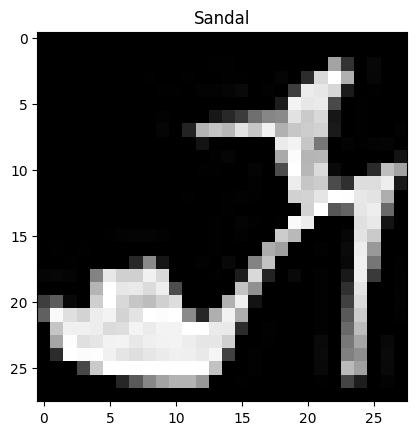

In [48]:
image=dataset[9][0]
y=dataset[9][1]

plt.imshow(image,cmap='gray', vmin=0, vmax=255)
plt.title(y)
plt.show()

In [49]:
import torchvision.transforms as transforms

In [50]:
# Combine two transforms: crop and convert to tensor. Apply the compose to MNIST dataset

croptensor_data_transform = transforms.Compose([transforms.CenterCrop(20), transforms.ToTensor()])
dataset = Dataset(csv_file=csv_path, data_dir=data_path, transform=croptensor_data_transform )
print("The shape of the first element tensor: ", dataset[0][0].shape)

The shape of the first element tensor:  torch.Size([1, 20, 20])


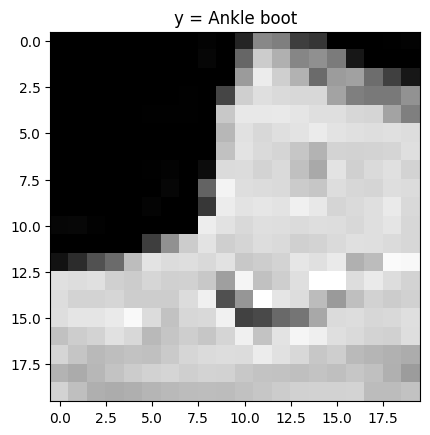

In [51]:
# Plot the first element in the dataset

show_data(dataset[0],shape = (20, 20))

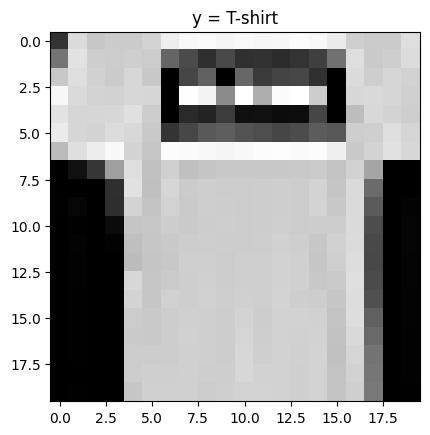

In [52]:
# Plot the second element in the dataset

show_data(dataset[1], shape = (20, 20))

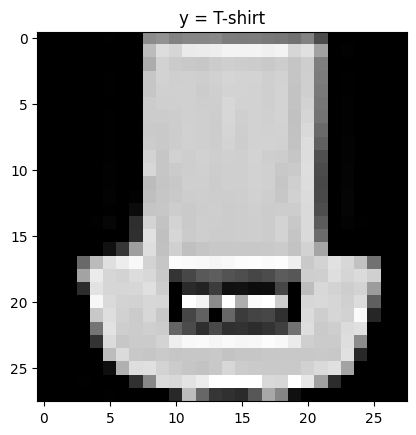

In [54]:
# Construct the compose. Apply it on MNIST dataset. Plot the image out.

fliptensor_data_transform = transforms.Compose([transforms.RandomVerticalFlip(p=1),transforms.ToTensor()])
dataset = Dataset(csv_file=csv_path, data_dir=data_path, transform=fliptensor_data_transform )
show_data(dataset[1])